Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°3**
## **Tema**: Operadores Genéticos ##

Integrantes:


*   Mamani, Pablo Ariel

*   Monteros, Milagros Maria
*   Felipe, Rocha

## Ejercicio 1
Implemente el operador de selección con Ruleta con pesos, completando el código dado.

In [ ]:
import random

def sel_ruleta(F, cant_selectos, eps):
    """ Operador de selección por torneos.
    Parametros:
    F: list
        Lista de valores de fitness de cada individuo de la población.
    cant_selectos: int
        Cantidad de individuos a seleccionar.
    eps: float
        Valor de fitness normalizado para el peor individuo.
    S: list
        Lista con las POSICIONES de los individuos seleccionados.
        Por ejemplo, si se tiene una población de 5 individuos, éstos
        están en la posición 0,1,2,3,4 en la población. Si sale selecto el
        primero y el último, se debe devolver un vector [0,4].
    """
    ###
    ### COMPLETAR EL CODIGO
    ###
        # Ajustar los fitness para que todos sean positivos (en caso de que eps haya que utilizarlo)
    min_fitness = min(F)
    ajustado = [f - min_fitness + eps for f in F]

    # Calcular la suma de los fitness ajustados para normalizar probabilidades
    suma_fitness = sum(ajustado)
    probabilidades = [f / suma_fitness for f in ajustado]

    # Calcular la ruleta acumulada
    ruleta = []
    acumulado = 0
    for p in probabilidades:
        acumulado += p
        ruleta.append(acumulado)

    S = []
    for _ in range(cant_selectos):
        r = random.random()
        for i, valor_ruleta in enumerate(ruleta):
            if r <= valor_ruleta:
                S.append(i)
                break

    return S #se debe devolver una lista de tamaño "cant_selectos"

# PRUEBA
F = [0.54, 0.28, 0.16, 0.12]
eps = 0.5
cant_tiros = 5

#aplicar seleccion
sel = sel_ruleta(F, cant_tiros, eps)

print('Posicion de individuos seleccionados:')
print(sel)

Posicion de individuos seleccionados:
[3, 1, 2, 0, 1]


## Ejercicio 2
Genere un histograma que muestre la probabilidad de ser seleccionado de cada individuo (basado en su fitness), y un histograma con la cantidad de veces que cada individuo es efectivamente seleccionado. Utilice una población con 10 individuos y el operador de seleccion implementado en el punto anterior sobre la función de evaluación f(x,y) = -sum(x^2 + y^2). ¿Qué diferencia hay al seleccionar 10, 100 y 1000 tiros con el operador dado?

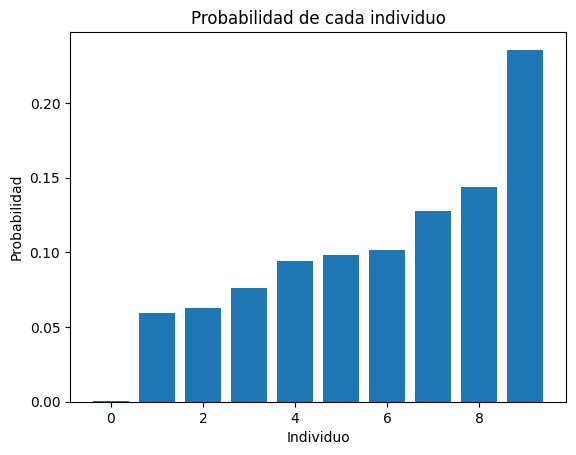

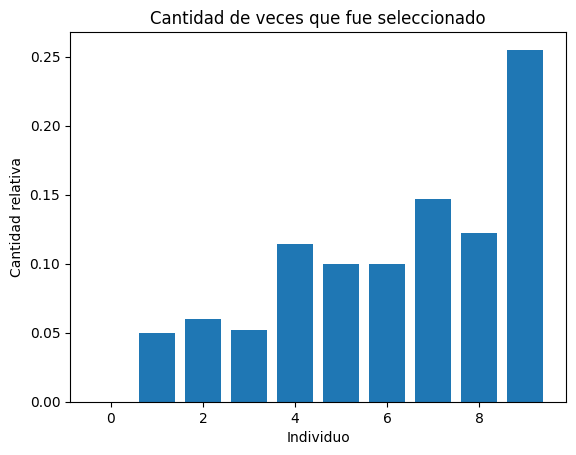

In [ ]:
import random
import matplotlib.pyplot as plt

def histograma(pop, fitness, p_selectos, eps):
    #estimo probabilidad de cada individuo de ser seleccionado
    min_f = min(fitness)
    f_norm = [fi - min_f + eps for fi in fitness]
    sum_f = sum(f_norm)
    prob = [fi / sum_f for fi in f_norm]

    #obtener cantidad relativa de soluciones obtenidas
    c = [0] * len(prob)
    for p in p_selectos:
        c[p] = c[p] + 1
    cant = [ci / len(p_selectos) for ci in c]

    #obtengo el orden en el que voy a graficar
    psort = sorted(range(len(prob)), key=lambda k: prob[k])

    #mostrar graficas
    plt.figure()
    plt.bar(range(len(prob)), [prob[p] for p in psort])
    plt.title('Probabilidad de cada individuo')
    plt.xlabel('Individuo')
    plt.ylabel('Probabilidad')

    plt.figure()
    plt.bar(range(len(cant)), [cant[p] for p in psort])
    plt.title('Cantidad de veces que fue seleccionado')
    plt.xlabel('Individuo')
    plt.ylabel('Cantidad relativa')

def generar_poblacion(bounds, cant_soluciones):
    pop = []
    for i in range(cant_soluciones):
        s = [random.random() * (b[1] - b[0]) + b[0] for b in bounds]
        pop.append(s)
    return pop

def fitness(S):
    return -sum([xi**2 for xi in S])

# PRUEBA
cant_soluciones = 10 #individuos
cant_tiros = 1000
eps = 0.1
bounds = [[0,10], [0,10]] #2 coordenadas para generar los individuos

#generar una poblacion de individuos de prueba
pop = generar_poblacion(bounds, cant_soluciones)
#evaluar cada individuo
F = [fitness(s) for s in pop]
#aplicar seleccion
sel = sel_ruleta(F, cant_tiros, eps)
#mostrar histograma
histograma(pop, F, sel, 0.1)

Con 10 tiros, la cantidad de veces que cada individuo es seleccionado puede tener mayor variabilidad y desviarse de la probabilidad teórica, que es la que
vemos en el primer histograma.

A medida que se incrementa la cantidad de tiros (100, 1000), la distribución de selecciones efectivas se aproxima mejor a las probabilidades reales, mostrando menor desviación y mayor estabilidad estadística. No van a ser las mismas por
un tema de aleatoriedad

## Ejercicio 3
Implemente el operador Uniform crossover, completando el código. Luego apliquelos a los dos individuos dados.

In [ ]:
import random

def xov_uniform(P1, P2):
    """Operador Uniform Crossover para Algoritmos Geneticos.
    Parametros:
    P1: list
        Lista correspondiente a uno de los individuos padres a cruzar.
    P2: list
        Lista correspondiente a uno de los individuos padres a cruzar.
    """
    ###
    ### COMPLETAR EL CODIGO
    ###
    mascara = [random.randint(0,1) for i in range(len(P1))]
    C1 = [P1[i] if a == 0 else P2[i] for i, a in enumerate(mascara)]
    C2 = [P2[i] if a == 0 else P1[i] for i, a in enumerate(mascara)]
    return C1, C2 #devolver listas del mismo tamaño que P1 y P2

P1 = [2.1, 9.3, 7.4, 1.8, 5.2]
P2 = [4.2, 1.6, 2.7, 6.4, 5.9]
print("Individuos Padres")
print(P1)
print(P2)

C1, C2 = xov_uniform(P1, P2)
print("Uniform Crossover")
print(C1)
print(C2)

Individuos Padres
[2.1, 9.3, 7.4, 1.8, 5.2]
[4.2, 1.6, 2.7, 6.4, 5.9]
Uniform Crossover
[4.2, 9.3, 7.4, 1.8, 5.2]
[2.1, 1.6, 2.7, 6.4, 5.9]


## Ejercicio 4
Implemente los siguientes operadores de mutación completando el código dado.
1. Boundary Mutation
2. Step Mutation

In [ ]:
import random

def mut_boundary(P, Bounds):
    """Step Mutation
    Parámetros
    P: list
        Vector correspondiente a un individuo.
    bounds: list
        Matriz que indica los valores maximo y minimo de cada coordenada.
    """
    C = P.copy()
    cut = random.randint(0,len(P)-1) #Elige una coordenada al azar entre 0 y el tamaño del vector
    C[cut] = bounds[cut][random.randint(0,1)] #Elige el limite al azar. HACIA donde voy
    return C

def mut_step(P, Bounds):
    """Step Mutation
    Parámetros
    P: list
        Vector correspondiente a un individuo.
    bounds: list
        Matriz que indica los valores maximo y minimo de cada coordenada.
    """

    ###
    ### COMPLETAR EL CODIGO
    ###
    C = P.copy()
    cut = random.randint(0,len(P)-1) #Elige una coordenada al azar entre 0 y el tamaño del vector
    if random.randint(0,1) == 0: #Elige un valor intermedio desde donde estoy parado y en unos de los limites
        C[cut] = random.random() * (bounds[cut][1] - P[cut]) + P[cut]
    else:
        C[cut] = random.random() * (P[cut] - bounds[cut][0]) + P[cut]

    return C #devolver lista del mismo tamaño que P

P = [2.1, 9.3, 7.4, 1.8, 5.2]
bounds = [[0,10], [0,10], [0,10], [0,10], [0,10]]

print("Individuo original")
print(P)

C = mut_boundary(P, bounds)
print("Boundary Mutation")
print(C)

C = mut_step(P, bounds)
print("Step Mutation")
print(C)

Individuo original
[2.1, 9.3, 7.4, 1.8, 5.2]
Boundary Mutation
[2.1, 9.3, 7.4, 10, 5.2]
Step Mutation
[2.1, 9.3, 7.4, 3.5668601786606304, 5.2]
